# Outcome Model: $\hat{f}(X, W, Z) = P(\hat{Y}=1 \mid X, W, Z)$

Trains a logistic regression classifier on the full SFM feature set $(X, W_\mathrm{cont}, W_\mathrm{disc}, Z)$
and wraps it in a PyTorch-compatible callable for use in NDE/NIE estimation and the recourse objective.

## 0. Imports

In [3]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score,
    classification_report, RocCurveDisplay,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
torch.serialization.add_safe_globals([StandardScaler])

sns.set_theme(
    style="whitegrid", context="paper", palette="colorblind",
    rc={
        "grid.color": "0.9", "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
        "legend.fontsize": 10, "xtick.labelsize": 10, "ytick.labelsize": 10,
        "figure.dpi": 300, "savefig.dpi": 300,
    },
)
PALETTE  = sns.color_palette("colorblind")
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── assumes flow notebook has already been run and these are in scope:
# X_tr, Z_tr, Wd_tr, Wc_tr, Y_tr
# X_va, Z_va, Wd_va, Wc_va, Y_va
# scaler, cfg

In [5]:
ckpt = torch.load("outputs/data/bar_tensors.pt", weights_only=False)

X_tr, Z_tr, Wd_tr, Wc_tr, Y_tr = ckpt["X_tr"], ckpt["Z_tr"], ckpt["Wd_tr"], ckpt["Wc_tr"], ckpt["Y_tr"]
X_va, Z_va, Wd_va, Wc_va, Y_va = ckpt["X_va"], ckpt["Z_va"], ckpt["Wd_va"], ckpt["Wc_va"], ckpt["Y_va"]
scaler    = ckpt["scaler"]
vocab     = ckpt["vocab"]
cfg       = ckpt["cfg"]
dim_x, dim_z, dim_wc, dim_wd = ckpt["dim_x"], ckpt["dim_z"], ckpt["dim_wc"], ckpt["dim_wd"]

print("Loaded tensors successfully")

Loaded tensors successfully


## 1. Assemble Feature Matrix

Concatenate all SFM roles into a single feature matrix $[X; W_\mathrm{cont}; W_\mathrm{disc}; Z]$.
Note that $X$ is included so the model can capture both direct and indirect effects — 
this is required for the NDE/NIE decomposition.

In [6]:
def assemble_features(
    X: torch.Tensor,
    Wc: torch.Tensor,
    Wd: torch.Tensor,
    Z: torch.Tensor,
) -> np.ndarray:
    """
    Concatenate (X, W_cont, W_disc, Z) into a single float32 numpy array.
    W_disc is cast to float for sklearn compatibility.
    Column order: [X | W_cont | W_disc | Z]
    """
    parts = [X]
    if Wc.shape[1] > 0:
        parts.append(Wc)
    if Wd.shape[1] > 0:
        parts.append(Wd.float())
    if Z.shape[1] > 0:
        parts.append(Z)
    return torch.cat(parts, dim=1).numpy().astype(np.float32)


X_feat_tr = assemble_features(X_tr, Wc_tr, Wd_tr, Z_tr)
X_feat_va = assemble_features(X_va, Wc_va, Wd_va, Z_va)
y_tr = Y_tr.numpy().astype(int)
y_va = Y_va.numpy().astype(int)

# Feature names for interpretability
feat_names = (
    cfg["sensitive"]
    + cfg["mediators_cont"]
    + cfg["mediators_disc"]
    + cfg["confounders"]
)

print(f"Feature matrix shape  — train: {X_feat_tr.shape}  val: {X_feat_va.shape}")
print(f"Features: {feat_names}")
print(f"Class balance — train: {y_tr.mean():.3f}  val: {y_va.mean():.3f}")

Feature matrix shape  — train: (15840, 5)  val: (3960, 5)
Features: ['race', 'lsat', 'gpa', 'gender', 'fam_inc']
Class balance — train: 0.954  val: 0.956


## 2. Train Logistic Regression

In [7]:
clf = LogisticRegression(
    penalty="l2",
    C=1.0,                  # inverse regularization strength
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
)
clf.fit(X_feat_tr, y_tr)

# ── Evaluation ────────────────────────────────────────────────────────────────
y_prob_tr = clf.predict_proba(X_feat_tr)[:, 1]
y_prob_va = clf.predict_proba(X_feat_va)[:, 1]
y_pred_va = clf.predict(X_feat_va)

print(f"Train AUC : {roc_auc_score(y_tr, y_prob_tr):.4f}")
print(f"Val   AUC : {roc_auc_score(y_va, y_prob_va):.4f}")
print(f"Val   Acc : {accuracy_score(y_va, y_pred_va):.4f}")
print()
print(classification_report(y_va, y_pred_va, target_names=["Fail", "Pass"]))

Train AUC : 0.7795
Val   AUC : 0.7787
Val   Acc : 0.9558

              precision    recall  f1-score   support

        Fail       0.45      0.03      0.05       174
        Pass       0.96      1.00      0.98      3786

    accuracy                           0.96      3960
   macro avg       0.71      0.51      0.52      3960
weighted avg       0.94      0.96      0.94      3960



c:\Users\andre\Documents\counterfactual-recourse\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 3. Coefficients

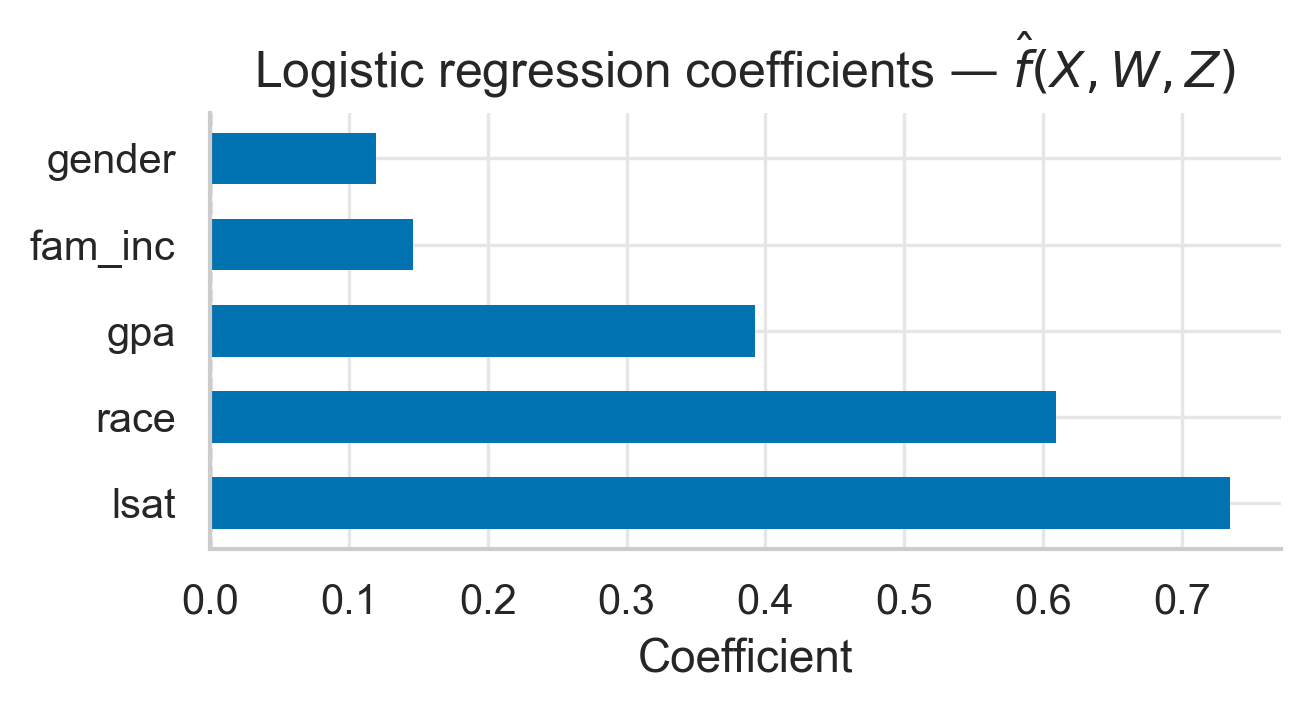

In [8]:
coefs = clf.coef_[0]
order = np.argsort(np.abs(coefs))[::-1]

fig, ax = plt.subplots(figsize=(4.5, 2.5))
colors = [PALETTE[0] if c > 0 else PALETTE[3] for c in coefs[order]]
ax.barh(
    [feat_names[i] for i in order],
    coefs[order],
    color=colors, height=0.6, edgecolor="none",
)
ax.axvline(0, color="0.4", lw=0.8, ls="--")
ax.set_xlabel("Coefficient")
ax.set_title(r"Logistic regression coefficients — $\hat{f}(X, W, Z)$")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/outcome_model_coefs.pdf", bbox_inches="tight")
plt.show()

## 4. Calibration & ROC

c:\Users\andre\Documents\counterfactual-recourse\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


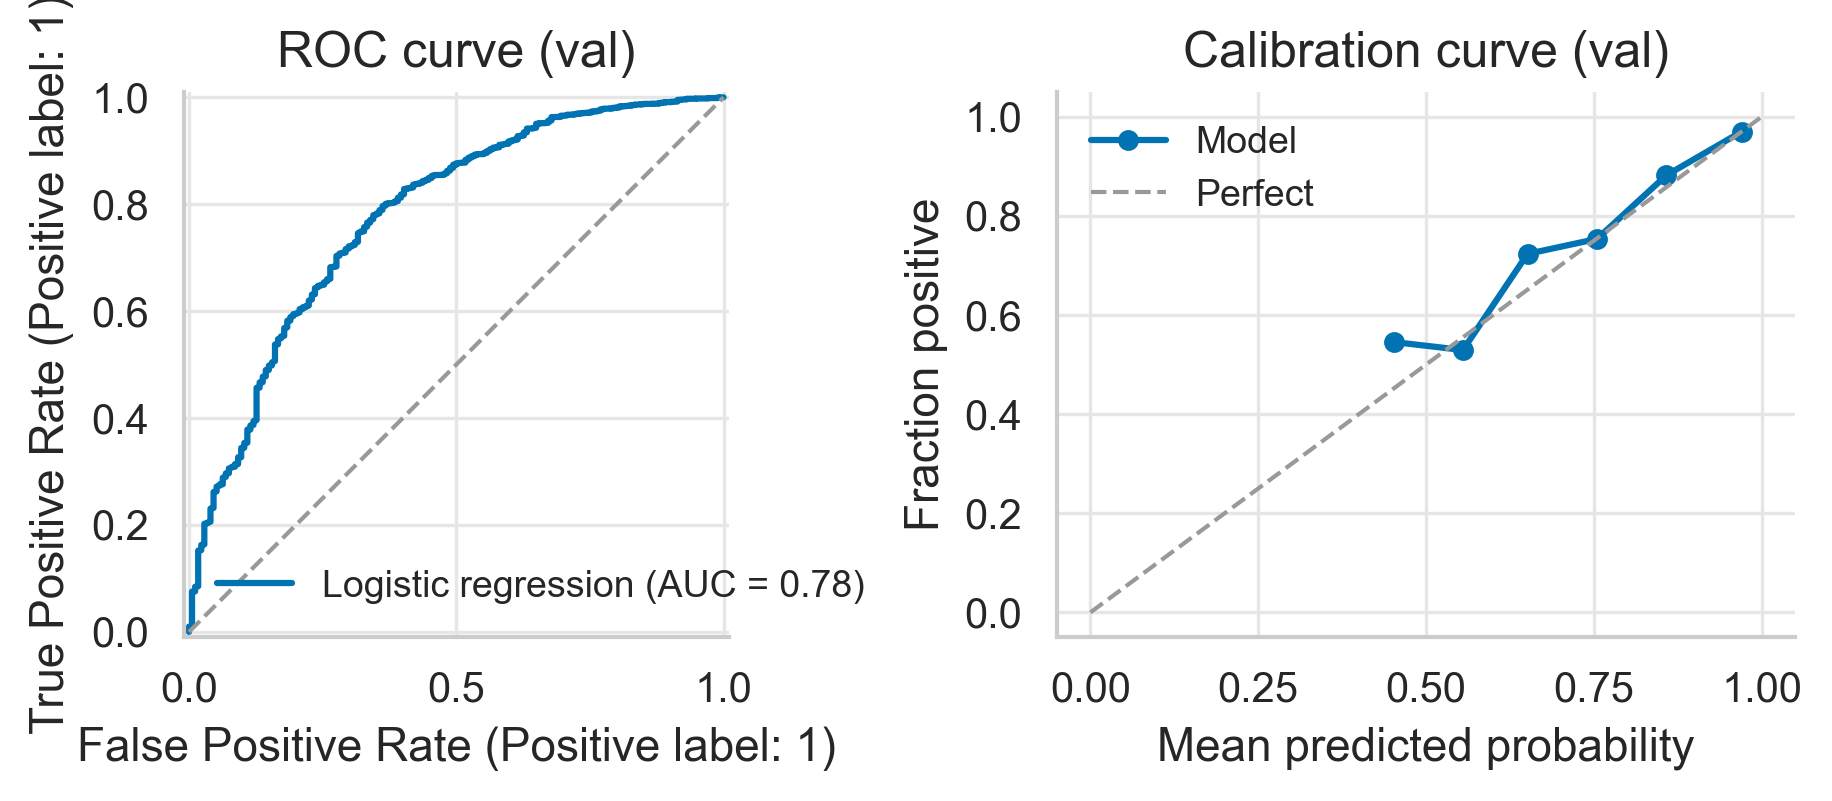

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.8))

# ── ROC ───────────────────────────────────────────────────────────────────────
RocCurveDisplay.from_predictions(
    y_va, y_prob_va, ax=axes[0],
    color=PALETTE[0], lw=1.5, name="Logistic regression",
)
axes[0].plot([0, 1], [0, 1], "--", color="0.6", lw=1)
axes[0].set_title("ROC curve (val)")
axes[0].legend(frameon=False, fontsize=9)
sns.despine(ax=axes[0])

# ── Calibration ───────────────────────────────────────────────────────────────
frac_pos, mean_pred = calibration_curve(y_va, y_prob_va, n_bins=10)
axes[1].plot(mean_pred, frac_pos, "o-", color=PALETTE[0], lw=1.5, ms=4, label="Model")
axes[1].plot([0, 1], [0, 1], "--", color="0.6", lw=1, label="Perfect")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Fraction positive")
axes[1].set_title("Calibration curve (val)")
axes[1].legend(frameon=False, fontsize=9)
sns.despine(ax=axes[1])

fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/outcome_model_eval.pdf", bbox_inches="tight")
plt.show()

## 5. Predicted Probability by Group

A key sanity check: does the model predict systematically different probabilities 
for Black vs White individuals before any recourse?

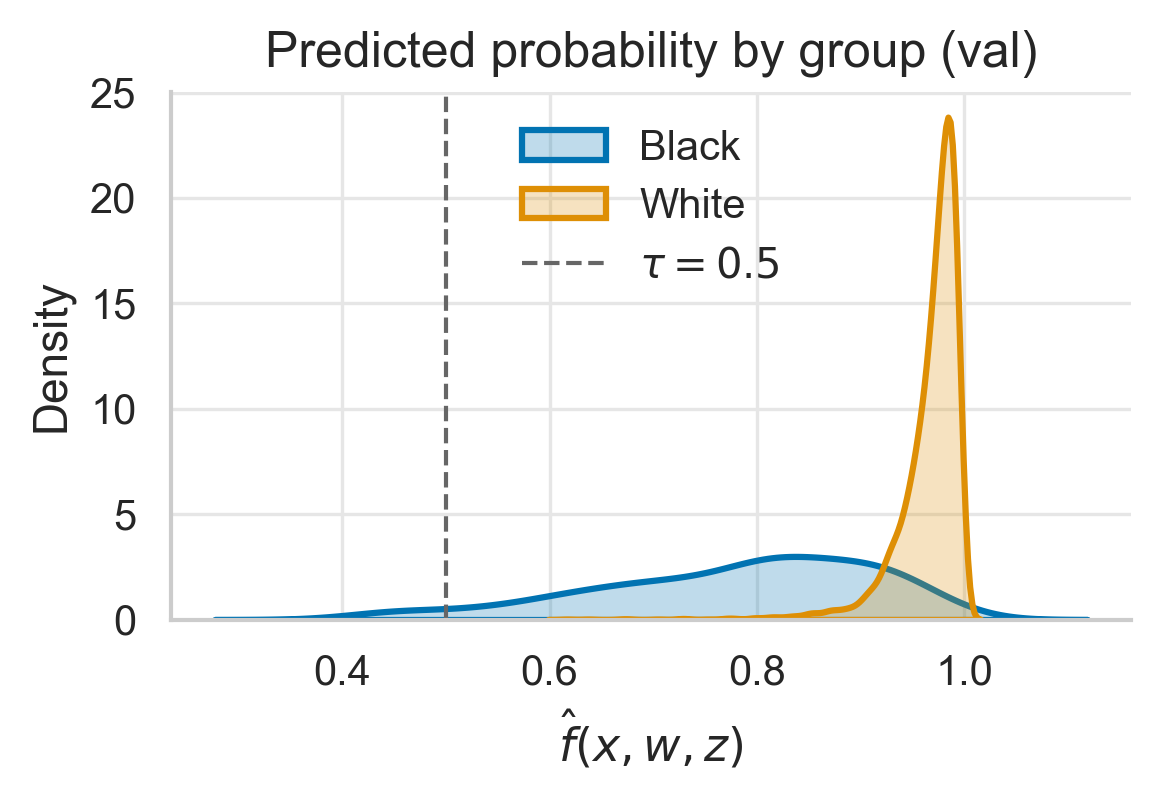

Black   mean P(pass) = 0.7780  pass rate = 0.7803
White   mean P(pass) = 0.9667  pass rate = 0.9686


In [10]:
GROUP_LABELS = {0: "Black", 1: "White"}

fig, ax = plt.subplots(figsize=(4.0, 2.8))
for g, color in zip([0, 1], [PALETTE[0], PALETTE[1]]):
    mask = (X_va[:, 0].numpy() == g)
    sns.kdeplot(
        y_prob_va[mask], ax=ax,
        color=color, lw=1.5, fill=True, alpha=0.25,
        label=GROUP_LABELS[g],
    )
ax.axvline(0.5, color="0.4", lw=1, ls="--", label="$\\tau = 0.5$")
ax.set_xlabel(r"$\hat{f}(x, w, z)$")
ax.set_ylabel("Density")
ax.set_title("Predicted probability by group (val)")
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/outcome_model_by_group.pdf", bbox_inches="tight")
plt.show()

# Print mean predicted probability by group
for g in [0, 1]:
    mask = (X_va[:, 0].numpy() == g)
    print(f"{GROUP_LABELS[g]:6s}  mean P(pass) = {y_prob_va[mask].mean():.4f}  "
          f"pass rate = {y_va[mask].mean():.4f}")

## 6. PyTorch-Compatible Wrapper

Wraps the sklearn classifier as a callable `(x, w_cont, z) -> (N,) tensor` 
for use in `estimate_nde_nie_for_individual` and the recourse objective.
Accepts tensors, returns tensors — no numpy in the calling code.

In [11]:
class OutcomeModel:
    """
    Thin wrapper around a fitted sklearn classifier.
    Provides a tensor interface matching the signature expected by
    estimate_nde_nie_for_individual and the recourse objective:

        prob = outcome_model(x, w_cont, z)   # (N,) float32 tensor

    W_disc columns (if any) are passed separately and concatenated internally.
    """

    def __init__(self, clf, w_disc_ref: torch.Tensor = None):
        """
        clf          : fitted sklearn classifier with predict_proba
        w_disc_ref   : (N, dim_wd) tensor used to infer dim_wd;
                       pass None if there are no discrete mediators
        """
        self.clf       = clf
        self.dim_wd    = w_disc_ref.shape[1] if w_disc_ref is not None else 0

    def __call__(
        self,
        x:      torch.Tensor,          # (N, dim_x)
        w_cont: torch.Tensor,          # (N, dim_wc)
        z:      torch.Tensor,          # (N, dim_z)
        w_disc: torch.Tensor = None,   # (N, dim_wd)  optional
    ) -> torch.Tensor:                 # (N,)
        parts = [x]
        if w_cont.shape[1] > 0:
            parts.append(w_cont)
        if w_disc is not None and w_disc.shape[1] > 0:
            parts.append(w_disc.float())
        elif self.dim_wd > 0:
            raise ValueError(
                "Model expects discrete mediators but w_disc was not provided."
            )
        if z.shape[1] > 0:
            parts.append(z)

        X_np   = torch.cat(parts, dim=1).detach().cpu().numpy().astype(np.float32)
        probs  = self.clf.predict_proba(X_np)[:, 1].astype(np.float32)
        return torch.tensor(probs)


outcome_model = OutcomeModel(clf, w_disc_ref=Wd_tr if Wd_tr.shape[1] > 0 else None)

# ── Quick sanity check ────────────────────────────────────────────────────────
probs = outcome_model(X_va[:5], Wc_va[:5], Z_va[:5])
print("Test output shape :", probs.shape)
print("Test probabilities:", probs.numpy().round(4))

Test output shape : torch.Size([5])
Test probabilities: [0.9809 0.9923 0.9748 0.9869 0.953 ]


## 7. Save Model

In [12]:
import pickle, os

SAVE_PATH = f"outputs/models/bar"
os.makedirs(SAVE_PATH, exist_ok=True)

with open(f"{SAVE_PATH}/outcome_model.pkl", "wb") as f:
    pickle.dump(clf, f)

print(f"Saved to {SAVE_PATH}/outcome_model.pkl")

Saved to outputs/models/bar/outcome_model.pkl


## 8. Load Model (for downstream notebooks)

In [ ]:
def load_outcome_model(path: str, w_disc_ref: torch.Tensor = None) -> OutcomeModel:
    with open(path, "rb") as f:
        clf_ = pickle.load(f)
    return OutcomeModel(clf_, w_disc_ref=w_disc_ref)

# Example:
# outcome_model = load_outcome_model(
#     "outputs/models/law_school/outcome_model.pkl",
#     w_disc_ref=Wd_va,
# )